In [2]:
# Import que vous pouvez vouloir pour le TP
import torch
import torch.nn as nn

import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import random_split

import torchvision
import torchvision.transforms as transforms
import numpy as np


import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

# Reproductibilité
torch.manual_seed(42)
np.random.seed(42)

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Calcul de la moyenne et de l'écart type pour nos images

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

dir = "./data"

transform_base = transforms.Compose([
    transforms.ToTensor()
])
dataset = datasets.ImageFolder(root=dir, transform=transform_base)
loader = DataLoader(dataset, batch_size=64, shuffle=False)

somme_totale = 0.0
somme_carres_totale = 0.0
nombre_total_pixels = 0

for images, _ in loader:
    somme_totale += images.sum()
    somme_carres_totale += (images ** 2).sum()
    nombre_total_pixels += images.numel()
moyenne = somme_totale / nombre_total_pixels
variance = (somme_carres_totale / nombre_total_pixels) - (moyenne ** 2)
ecart_type = torch.sqrt(variance)




Taille du train set : 30384
Taille du test set  : 7596
Nombre de classes   : 10
Noms des classes    : ['coastguard_scaled', 'containership_scaled', 'corvette_scaled', 'cruiser_scaled', 'cv_scaled', 'destroyer_scaled', 'methanier_scaled', 'smallfish_scaled', 'submarine_scaled', 'tug_scaled']
Dimensions d'une image : torch.Size([1, 128, 192])  (C x H x W)
Classe de l'image      : submarine_scaled


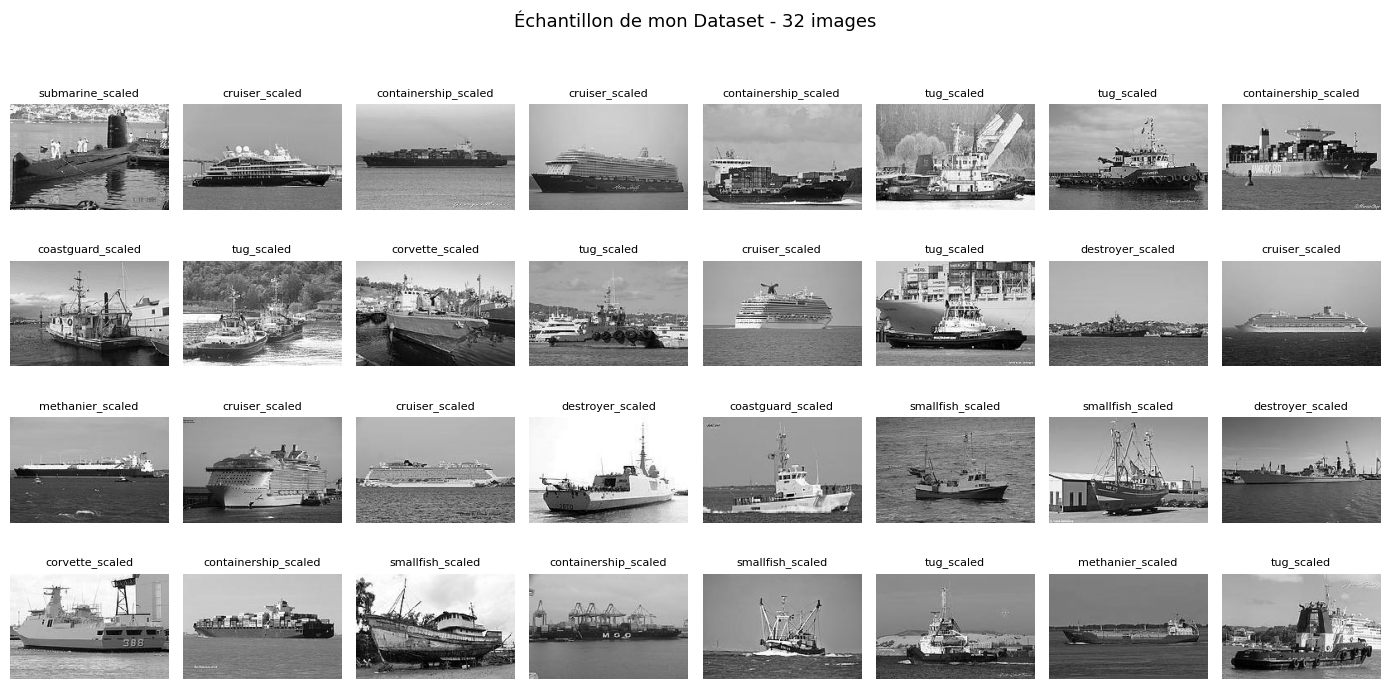

In [3]:
transform_base = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(moyenne.item(), ecart_type.item())
])

dataset_complet = datasets.ImageFolder(root='./data/ships_gray/ships_gray', transform=transform_base)
classes = dataset_complet.classes
taille_totale = len(dataset_complet)
taille_train = int(0.8 * taille_totale)
taille_test = taille_totale - taille_train


trainset, testset = random_split(dataset_complet, [taille_train, taille_test])


print(f"Taille du train set : {len(trainset)}")
print(f"Taille du test set  : {len(testset)}")
print(f"Nombre de classes   : {len(classes)}")
print(f"Noms des classes    : {classes}")

img, label = trainset[0]
print(f"Dimensions d'une image : {img.shape}  (C x H x W)")
print(f"Classe de l'image      : {classes[label]}")

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle('Échantillon de mon Dataset - 32 images', fontsize=13, y=1.02)

for i, ax in enumerate(axes.flat):
    img, label = trainset[i]

    img_display = img * ecart_type.item() + moyenne.item()

    img_display = img_display.squeeze()

    ax.imshow(img_display.numpy(), cmap='gray', vmin=0, vmax=1)

    ax.set_title(classes[label], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

Taille du train set : 30384
Taille du test set  : 7596


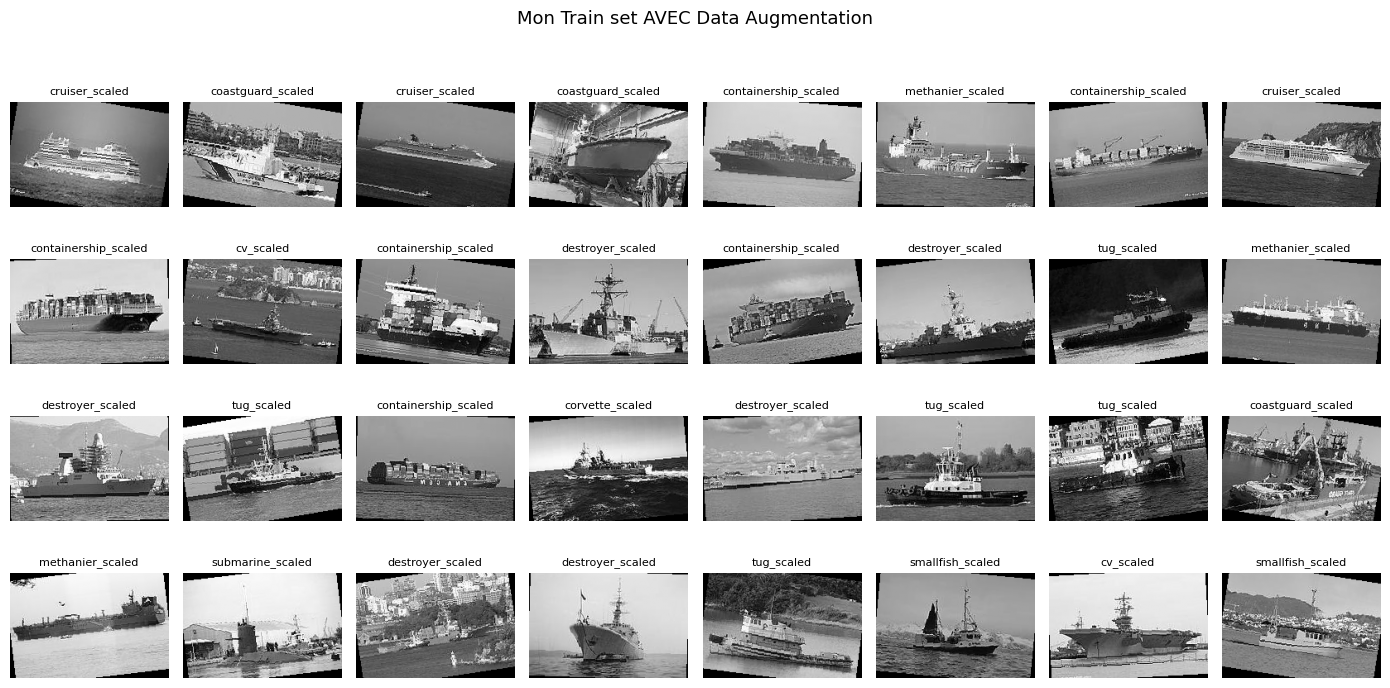

In [10]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, Dataset
import matplotlib.pyplot as plt


transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize([moyenne.item()], [ecart_type.item()])
])


transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize([moyenne.item()], [ecart_type.item()])
])


dataset_brut = datasets.ImageFolder(root='./data/ships_gray/ships_gray')
classes = dataset_brut.classes

taille_totale = len(dataset_brut)
taille_train = int(0.8 * taille_totale)
taille_test = taille_totale - taille_train


trainset_brut, testset_brut = random_split(dataset_brut, [taille_train, taille_test])

class AugTransform(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        img, label = self.subset[index]

        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.subset)

trainset = AugTransform(trainset_brut, transform=transform_train)
testset = AugTransform(testset_brut, transform=transform_test)


train_loader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=0)

test_loader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=0)

print(f"Taille du train set : {len(trainset)}")
print(f"Taille du test set  : {len(testset)}")

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle('Mon Train set AVEC Data Augmentation', fontsize=13, y=1.02)

for i, ax in enumerate(axes.flat):
    img, label = trainset[i]

    img_display = img * ecart_type.item() + moyenne.item()
    img_display = img_display.squeeze()

    ax.imshow(img_display.numpy(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(classes[label], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, dropout_rate=0.4):
        super().__init__()

        # Bloc conv
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 128, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)

        # 🔥 clé magique
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.dropout = nn.Dropout(dropout_rate)

        # après global pool → 128 features seulement
        self.fc1 = nn.Linear(128, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        # 🔥 rend la taille indépendante
        x = self.global_pool(x)

        x = x.view(x.size(0), -1)  # (B, 128)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))

        return self.fc3(x)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        # 🔥 IMPORTANT : pooling AVANT flatten
        x = self.global_pool(x)

        x = x.view(x.size(0), -1)  # (B, 128)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))

        return self.fc3(x)                                       # -> (B, 10)


simple_model = CNN()
print(simple_model)

# Comptage des paramètres
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nNombre de paramètres entraînables : {count_params(simple_model):,}")

print(images.shape)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=128, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_f

In [12]:
num_epochs = 10

model = CNN()
dummy = torch.randn(1, 1, 32, 32)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
print(model)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:   # IMPORTANT
        optimizer.zero_grad()

        outputs = model(images)           # now 4D input OK
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=128, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_f

KeyboardInterrupt: 

In [ ]:
# --- Entraînement du SimpleCNN ---
print("=" * 65)
print("Entraînement de CNN")
print("=" * 65)

NUM_EPOCHS=30

simple_model = SimpleCNN().to(device)
history_simple = train_model(
    simple_model, trainloader
    num_epochs=NUM_EPOCHS, lr=1e-3, device=device, model_name='CNN'
)

Entraînement de SimpleCNN


NameError: name 'valloader' is not defined